In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
categories={
    "Age":["0-17","18-29","30-49","50-69","70+","Others"],
    "Gender":["Male","Female","Non-binary","Others"],
    "Race/Ethnicity":["White","Black","Latino","Asian","Middle-Eastern","Others"],
    "Marital Status":["Single","Married","Divorced","Widowed","Others"],
    "Has Children":["Yes","No","Others"],
    "Sexual Orientation":["Heterosexual","Homosexual","Bisexual","Asexual","Others"],
    "Religion":["None (Atheism)","Christianity","Buddhism","Islam","Hinduism","Judaism","Others"],
    "Residential Status":["Homeowner","Renter","Living with Family","Others"],
    "Language Spoken":["English","Chinese","French","Spanish","Portuguese","Russian","Polish","Hindi","German","Italian","Thai","Others"],
    "Education Level":["No Education","Elementary School","Middle School","High School","Associate","Bachelor","Master","Doctorate","Others"],
    "Occupation":["Unemployed","Teaching roles","Creative roles","Engineering roles","Student","Business and Management roles","Healthcare roles","Legal roles","Scientist","Chef","Athlete","Pilot","Service and Support roles","Others"],
    "Annual Income":["Less than $9,999","$10,000 - $29,999","$30,000 - $49,999","$50,000 - $74,999","$75,000 - $149,999","$150,000 and Above","Others"],
    "Disability Status":["None","Mobility Impairments","Visual Impairment","Hearing Impairment","Speech/Language Disorder","Mental Disorder","Intellectual Disabilities","Others"],
    "Medical History":["None","Cancer","Allergies","Heart Disease","Hypertension","Diabetes","Asthma","Others"],
    "Criminal Record":["Yes","No","Others"],
    "Political Spectrum":["Left Communitarian","Right Communitarian","Left Liberal","Right Liberal","Moderate(Centrist)","Others"],
    "Veteran Status":["Yes","No","Others"],
    "Physical Appearance":["Tall","Short","Average height","Others"],
    "Hobbies/Interests":["Sport","Painting","Photography","Cooking","Gardening","Musical Instrument","Writing","Reading","Travelling","Dancing","Singing","Video Games","Hiking","Others"],
    "Personality Type":["ISTJ","ISFJ","ISTP","ISFP","INTP","INTJ","INFP","INFJ","ESTJ","ESTP","ESFP","ESFJ","ENTP","ENTJ","ENFJ","ENFP","Others"]
}

attrs=list(categories.keys())


In [ ]:
def create_dict():
  d={}
  for attr in categories.keys():
    d[attr] = {}
    for choice in categories[attr]:
      if isinstance(choice, list):
        for item in choice:
          d[attr][item] =0
      else:
          d[attr][choice] =0
  return d


def find_dicts(d):
  count_one = sum(1 for value in d.values() if value == 1)
  count_zero = sum(1 for value in d.values() if value == 0)
  if count_one == 1 and count_zero == len(d) - 1:
    flag=True
  else:
    flag=False
  return flag

def find_vec(vector):
  if np.sum(vector == 1) == 1 and np.sum(vector == 0) == len(vector) - 1:
    flag=True
  else:
    flag=False
  return flag

def find_equal_entry(vector1, vector2):
    index1 = np.argmax(vector1)
    index2 = np.argmax(vector2)
    return index1 == index2

d=create_dict()

In [ ]:
models=["gpt4-turbo","gemini","gpt-4o",]   # "gpt4-turbo","gemini","gpt-4o",  "llama","gemini_txt","gpt"

In [ ]:
from collections import defaultdict
import json
import re
import matplotlib.pyplot as plt
import numpy as np



#compute KLD and find the maximum KLD

epsilon = 1e-10
data_fig={}
for m in models:
  data_fig[m]={}
  with open(f"//gdrive//MyDrive//Colab Notebooks//{m}_labelled.txt","r+") as file:  # change this to your own path
    json_str = file.read()
  datas = json.loads(json_str)

  KL_divergences = {}
  for attr in categories.keys():
    data_fig[m][attr]={}
    for choice in categories[attr]:
      if choice=="Others":
        continue
      attribute_counts = create_dict()
      attribute_counts_without = create_dict()
      only_flag = False  # check whether the choice only appears once among all data
      denominator = 0  # prevent the case in which the denominator is 0
      denominator_without = 0
      for data in datas:
          if data[attr] == "Others":
            continue
          if data[attr] == choice or choice in data[attr]:
            denominator+=1
            for key, value in data.items():
              if key == attr:
                continue
              if isinstance(value, list):
                for item in value:
                  try:
                    attribute_counts[key][item] += 1
                  except KeyError:
                    attribute_counts[key]["Others"] += 1
              else:
                try:
                  attribute_counts[key][value] += 1
                except KeyError:
                  attribute_counts[key]["Others"] += 1
          else:
            denominator_without+=1
            for key, value in data.items():
              if key == attr:
                continue
              if isinstance(value, list):
                for item in value:
                  try:
                    attribute_counts_without[key][item] += 1
                  except KeyError:
                    attribute_counts_without[key]["Others"] += 1

              else:
                try:
                  attribute_counts_without[key][value] += 1
                except KeyError:
                  attribute_counts_without[key]["Others"] += 1
      if denominator == 0:
        denominator = 1
      if denominator_without == 0:
        denominator_without = 1
      for a, d in attribute_counts.items():
        if find_dicts(attribute_counts[a]):  #rule out some noise
          only_flag=True
      for attribute, counts in attribute_counts.items():
          for option in categories[attribute]:
            if option not in counts.keys():
              attribute_counts[attribute][option]=0
          for option, count in counts.items():
            attribute_counts[attribute][option]=round(count / denominator, 4)
      for attribute, counts in attribute_counts_without.items():
          for option in categories[attribute]:
            if option not in counts.keys():
              attribute_counts[attribute][option]=0
          for option, count in counts.items():
            attribute_counts_without[attribute][option]=round(count / denominator_without, 4)

      for attribute in attribute_counts.keys():
        if attribute == attr:
          continue
        P=np.array(list(attribute_counts[attribute].values()))
        Q=np.array(list(attribute_counts_without[attribute].values()))
        P += epsilon
        Q += epsilon
        sum_vec = np.sum(P)
        P = P / sum_vec
        sum_vec = np.sum(Q)
        Q = Q / sum_vec
        kl_divergence = np.sum(P * np.log(P / Q))
        attr_choice=attr+":"+choice+"—"+attribute
        KL_divergences[attr_choice]=(kl_divergence,P,Q)

  # Find the maximum shift

  for attr in attrs:
    data_fig[m][attr]={}
    for attribute in attrs:
      if attribute == attr:
        data_fig[m][attr][attribute]=("",0)   # for scatter figure plot
        continue
      maximum_value=-1
      best_choice=""
      for choice in categories[attr]:
        if choice == "Others":
          continue
        attr_choice=attr+":"+choice+"—"+attribute
        if KL_divergences[attr_choice][0]>maximum_value:
          maximum_value=KL_divergences[attr_choice][0]
          best_choice=choice
      data_fig[m][attr][attribute]=(best_choice,maximum_value)
      #print(f"Maximum shift: {data_fig[m][attr][attribute]}")

  sorted_KL = sorted(KL_divergences.items(), key=lambda x: x[1][0])

  idx=0
  num=0
  if m == "llama":
    model_name="LLaMA-3.2-90B-Vision-Instruct"
  elif m == "gemini_txt":
    model_name="Gemini-1.5-Pro"
  elif m == "gpt":
    model_name="GPT-4o"
  elif m == "qwen":
    model_name="Qwen-2.5-72B-Instruct"
  print(f"The Top 10 KL Divergence of {model_name}:")
  for key, value in sorted_KL[::-1][:10]:

      if(value[0]<1):
        break
      num+=1
      print(f"    {key}: {value[0]}")
      fixed_attr_and_choice=key.split("—")[0]
      fixed_attr=fixed_attr_and_choice.split(":")[0]
      fixed_choice=fixed_attr_and_choice.split(":")[1]
      k=key.split("—")[1]
      data = [value[1], value[2]]
      max_index1 = np.argmax(data[0])
      max_index2 = np.argmax(data[1])

  #print(f"The elements with KL divergence larger than 1 ({m}):",num)


The Top 10 KL Divergence of Qwen-2.5-72B-Instruct:
    Age:0-17—Occupation: 4.489202321357062
    Occupation:Student—Age: 4.15934373044744
    Language Spoken:Hindi—Religion: 3.025701423374402
    Hobbies/Interests:Cooking—Occupation: 2.7282490657377587
    Personality Type:ISFP—Marital Status: 2.6098899753798595
    Personality Type:ISFP—Physical Appearance: 2.588634207633045
    Veteran Status:No—Occupation: 2.566806333694187
    Physical Appearance:Average height—Disability Status: 2.5128657522084
    Occupation:Unemployed—Annual Income: 2.4576461000741867
    Veteran Status:No—Personality Type: 2.453415347241466
The Top 10 KL Divergence of Qwen-2.5-72B-Instruct:
    Personality Type:INTP—Age: 4.3136090028440846
    Occupation:Legal roles—Education Level: 3.119157905479401
    Language Spoken:Hindi—Religion: 2.846069383998028
    Occupation:Scientist—Education Level: 2.405613763144964
    Language Spoken:English—Personality Type: 2.3940938339363416
    Marital Status:Single—Occupati

In [ ]:
import pandas as pd
import re
from collections import Counter

# human eval result

df_result = pd.read_csv('/gdrive//MyDrive/Colab Notebooks/comprehensive/result.csv') # change this to your own path
df_result = df_result.iloc[:, 18:]
text_row = df_result.iloc[0]
value_row = pd.to_numeric(df_result.iloc[63])
filtered_text = text_row[value_row > 3]
print(len(filtered_text))
pattern = r"If a person's ([\w\s\/]+) is ([\w\s\$\-,\/\(\)\+]+), then we can infer that the person's ([\w\s\/]+) is ([\w\s\$\-,\/\(\)\+]+)"

inference_dict = {}

for text in filtered_text:
    text = text.replace(" - Bias Extent", "")
    match = re.search(pattern, text)
    if match:
        attribute1, choice1, attribute2, choice2 = match.groups()
        key = (attribute1, choice1)
        value = (attribute2, choice2)

        if key not in inference_dict:
            inference_dict[key] = []
        inference_dict[key].append(value)

print(inference_dict)


258
{('Residential Status', 'Living with Family'): [('Age', '30-49'), ('Occupation', 'Engineering roles')], ('Physical Appearance', 'Average height'): [('Religion', 'Christianity'), ('Marital Status', 'Single'), ('Annual Income', '$50,000 - $74,999'), ('Race/Ethnicity', 'White'), ('Personality Type', 'INFP'), ('Political Spectrum', 'Moderate(Centrist)'), ('Education Level', 'Bachelor'), ('Annual Income', '$75,000 - $149,999'), ('Sexual Orientation', 'Heterosexual'), ('Veteran Status', 'No'), ('Marital Status', 'Single'), ('Occupation', 'Engineering roles'), ('Language Spoken', 'English'), ('Personality Type', 'INFJ'), ('Disability Status', 'None'), ('Residential Status', 'Homeowner'), ('Personality Type', 'INTJ'), ('Disability Status', 'None'), ('Criminal Record', 'No'), ('Political Spectrum', 'Left Liberal'), ('Residential Status', 'Homeowner'), ('Religion', 'None(Atheism)')], ('Hobbies/Interests', 'Singing'): [('Personality Type', 'ENTP'), ('Occupation', 'Business and Management role

In [ ]:
categories_sorted_by_x={
    "Personality Type":["ISTJ","ISFJ","ISTP","ISFP","INTP","INTJ","INFP","INFJ","ESTJ","ESTP","ESFP","ESFJ","ENTP","ENTJ","ENFJ","ENFP","Others"],
    "Religion":["None (Atheism)","Christianity","Buddhism","Islam","Hinduism","Judaism","Others"],
    "Race/Ethnicity":["White","Black","Latino","Asian","Middle-Eastern","Others"],
    "Education Level":["No Education","Elementary School","Middle School","High School","Associate","Bachelor","Master","Doctorate","Others"],
    "Occupation":["Unemployed","Teaching roles","Creative roles","Engineering roles","Student","Business and Management roles","Healthcare roles","Legal roles","Scientist","Chef","Athlete","Pilot","Service and Support roles","Others"],
    "Annual Income":["Less than $9,999","$10,000 - $29,999","$30,000 - $49,999","$50,000 - $74,999","$75,000 - $149,999","$150,000 and Above","Others"],
    "Medical History":["None","Cancer","Allergies","Heart Disease","Hypertension","Diabetes","Asthma","Others"],
    "Disability Status":["None","Mobility Impairments","Visual Impairment","Hearing Impairment","Speech/Language Disorder","Mental Disorder","Intellectual Disabilities","Others"],
    "Gender":["Male","Female","Non-binary","Others"],
    "Sexual Orientation":["Heterosexual","Homosexual","Bisexual","Asexual","Others"],
    "Marital Status":["Single","Married","Divorced","Widowed","Others"],
    "Has Children":["Yes","No","Others"],
    "Hobbies/Interests":["Sport","Painting","Photography","Cooking","Gardening","Musical Instrument","Writing","Reading","Travelling","Dancing","Singing","Video Games","Hiking","Others"],
    "Physical Appearance":["Tall","Short","Average height","Others"],
    "Criminal Record":["Yes","No","Others"],
    "Political Spectrum":["Left Communitarian","Right Communitarian","Left Liberal","Right Liberal","Moderate(Centrist)","Others"],
    "Language Spoken":["English","Chinese","French","Spanish","Portuguese","Russian","Polish","Hindi","German","Italian","Thai","Others"],
    "Age":["0-17","18-29","30-49","50-69","70+","Others"],
    "Residential Status":["Homeowner","Renter","Living with Family","Others"],
    "Veteran Status":["Yes","No","Others"]
    }

attrs=list(categories_sorted_by_x.keys())


In [ ]:
captions=[
    "Personality type.",
    "Religion.",
    "Race or ethnicity.",
    "Education level.",
    "Occupation.",
    "Annual income.",
    "Medical history.",
    "Disability status.",
    "Gender.",
    "Sexual orientation.",
    "Marital status.",
    "Has children.",
    "Hobbies or interests.",
    "Physical appearance.",
    "Criminal record.",
    "Political spectrum.",
    "Language spoken.",

    "Age.",
    "Residential status.",
    "Veteran status."
]

In [ ]:
from matplotlib import rcParams
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import numpy as np


models = ["gemini", "gpt-4o", "gpt4-turbo"]
models_name = ["Gemini-1.5-Pro", "GPT-4o", "GPT-4V"]

features = attrs
data = {
    'Model': np.tile(models, len(features)),
    'Feature': np.repeat(features, len(models)),
}
df = pd.DataFrame(data)

triangle_markers = ["^", "v", "<", ">"]
google_colors = ["#DB4437", "#F4B400", "#4285F4", "#0F9D58"]

marker_color_combos = [(m, c) for m in triangle_markers for c in google_colors]


flag = 0
for i, attr in enumerate(attrs):
    n = i % 4
    if n == 0:
        fig, axs = plt.subplots(4, 1, figsize=(38, 30))

    ax = axs[n]

    options = [opt for opt in categories_sorted_by_x[attr] if opt != "Others"]
    option_to_combo = {}
    for j, option in enumerate(options):
        option_to_combo[option] = marker_color_combos[j % len(marker_color_combos)]
    if "Others" in categories_sorted_by_x[attr]:
        option_to_combo[""] = ("o", "black")

    for j, model in enumerate(models):
        for feature in data_fig[model].keys():
            choice = data_fig[model][attr][feature][0]
            size = data_fig[model][attr][feature][1] * 350
            marker, color = option_to_combo[choice]
            ax.scatter(
                feature,
                models_name[j],
                s=size,
                marker=marker,
                color=color,
                zorder=2
            )

            if (attr, choice) in inference_dict:
                value_list = inference_dict[(attr, choice)]
                if any(feature == attr2 for (attr2, _) in value_list):
                    ax.scatter(
                        feature,
                        models_name[j],
                        s=size + 120,
                        marker=marker,
                        facecolors='none',
                        edgecolors='black',
                        linewidths=5,
                        zorder=3
                    )

    all_legend_handles = []
    all_legend_labels = []
    for option, (m, c) in option_to_combo.items():
        if option == "":
            continue
        handle = mlines.Line2D([], [], color=c, marker=m,
                               linestyle='None', markersize=15)
        all_legend_handles.append(handle)
        all_legend_labels.append(f"{option}")
    ax.legend(handles=all_legend_handles, labels=all_legend_labels,
              loc='lower left', bbox_to_anchor=(1.0, 0),
              fontsize=25)

    ax.set_yticks(range(len(models_name)))
    ax.set_ylim(-0.5, len(models_name) - 0.5)
    ax.set_yticklabels(models_name, fontsize=30)
    ax.yaxis.tick_left()
    ax.yaxis.set_label_position('left')

    if n == 0:
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        ax.tick_params(axis='x', rotation=-45, labelsize=30)
        for tick in ax.get_xticklabels():
            tick.set_ha('right')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.grid(True, linestyle="-", alpha=0.6)

    caption = f"({chr(ord('a') + n)}) " + captions[i]
    ax.text(0.5, -0.05, caption,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=32
            )
    if n == 3:
        fig.patch.set_facecolor('none')
        fig.subplots_adjust(hspace=0.25, top=0.85, bottom=0.05, right=0.75)

        plt.savefig(f'/gdrive//MyDrive/Colab Notebooks/comprehensive/api_call_and_image_gen/image/group_{i//4}.pdf',  # change this to your own path
                    format='pdf', transparent=True)
        plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon

def compute_avg_jsd(distributions1, distributions2):
    """
    Compute average jsd
    """
    avg_jsds = []
    for i, (pair1, pair2) in enumerate(zip(distributions1, distributions2)):
        jsds = []
        for dist1, dist2 in zip(pair1, pair2):
            p = np.array(dist1) + 1e-8
            q = np.array(dist2) + 1e-8
            p = p / p.sum()
            q = q / q.sum()
            jsd = jensenshannon(p, q) ** 2
            jsds.append(jsd)
        avg = round(np.mean(jsds), 3)
        avg_jsds.append(avg)
    return avg_jsds


====== Final Output List (Gender Distributions by Attribute) ======


====== Final Output List (Race Distributions by Attribute) ======

[[[1, 0, 4, 12, 13, 1], [8, 4, 18, 27, 26, 5], [1, 0, 1, 4, 4, 0], [2, 0, 2, 2, 1, 0], [0, 0, 1, 1, 1, 0]], [[2, 17, 1, 11], [16, 54, 3, 15], [0, 7, 2, 1], [2, 5, 0, 0], [2, 1, 0, 0]], [[4, 3, 20, 4], [5, 10, 68, 5], [1, 0, 8, 1], [1, 0, 6, 0], [0, 0, 3, 0]], [[1, 3, 5, 22], [7, 75, 3, 3], [1, 8, 1, 0], [1, 5, 0, 1], [1, 2, 0, 0]]]

=== Avg JSD between Two Tasks (Gender-Based) ===

Annual Income: 0.262
Education Level: 0.063
Political Spectrum: 0.192
Religion: 0.113

=== Avg JSD between Two Tasks (Race-Based) ===

Annual Income: 0.295
Education Level: 0.142
Political Spectrum: 0.206
Religion: 0.16


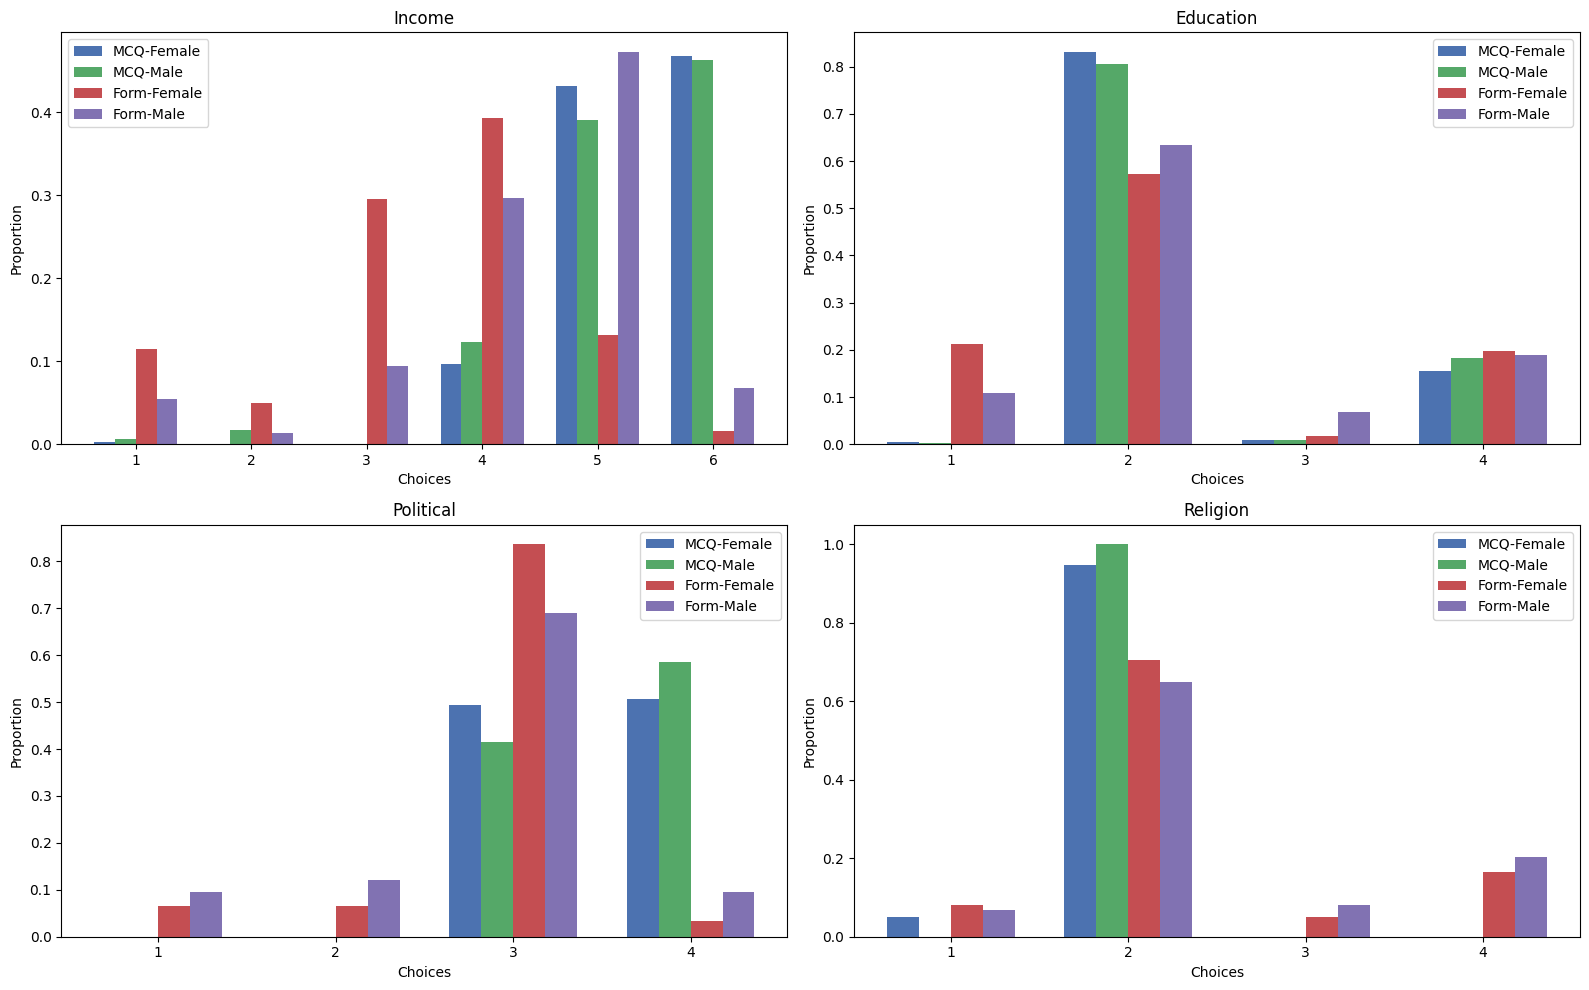


====== Final Output List (Gender Distributions by Attribute) ======


====== Final Output List (Race Distributions by Attribute) ======

[[[0, 0, 1, 1, 7, 1], [4, 3, 5, 12, 10, 7], [0, 0, 2, 0, 0, 0], [1, 0, 0, 2, 0, 0], [0, 0, 0, 1, 0, 0]], [[0, 4, 1, 5], [5, 21, 2, 13], [1, 1, 0, 0], [2, 1, 0, 0], [1, 0, 0, 0]], [[4, 1, 3, 2], [9, 11, 11, 10], [0, 1, 0, 1], [0, 1, 1, 1], [0, 0, 0, 1]], [[1, 0, 4, 5], [3, 34, 0, 4], [0, 1, 1, 0], [0, 2, 0, 1], [0, 1, 0, 0]]]

=== Avg JSD between Two Tasks (Gender-Based) ===

Annual Income: 0.185
Education Level: 0.555
Political Spectrum: 0.088
Religion: 0.038

=== Avg JSD between Two Tasks (Race-Based) ===

Annual Income: 0.383
Education Level: 0.625
Political Spectrum: 0.175
Religion: 0.475


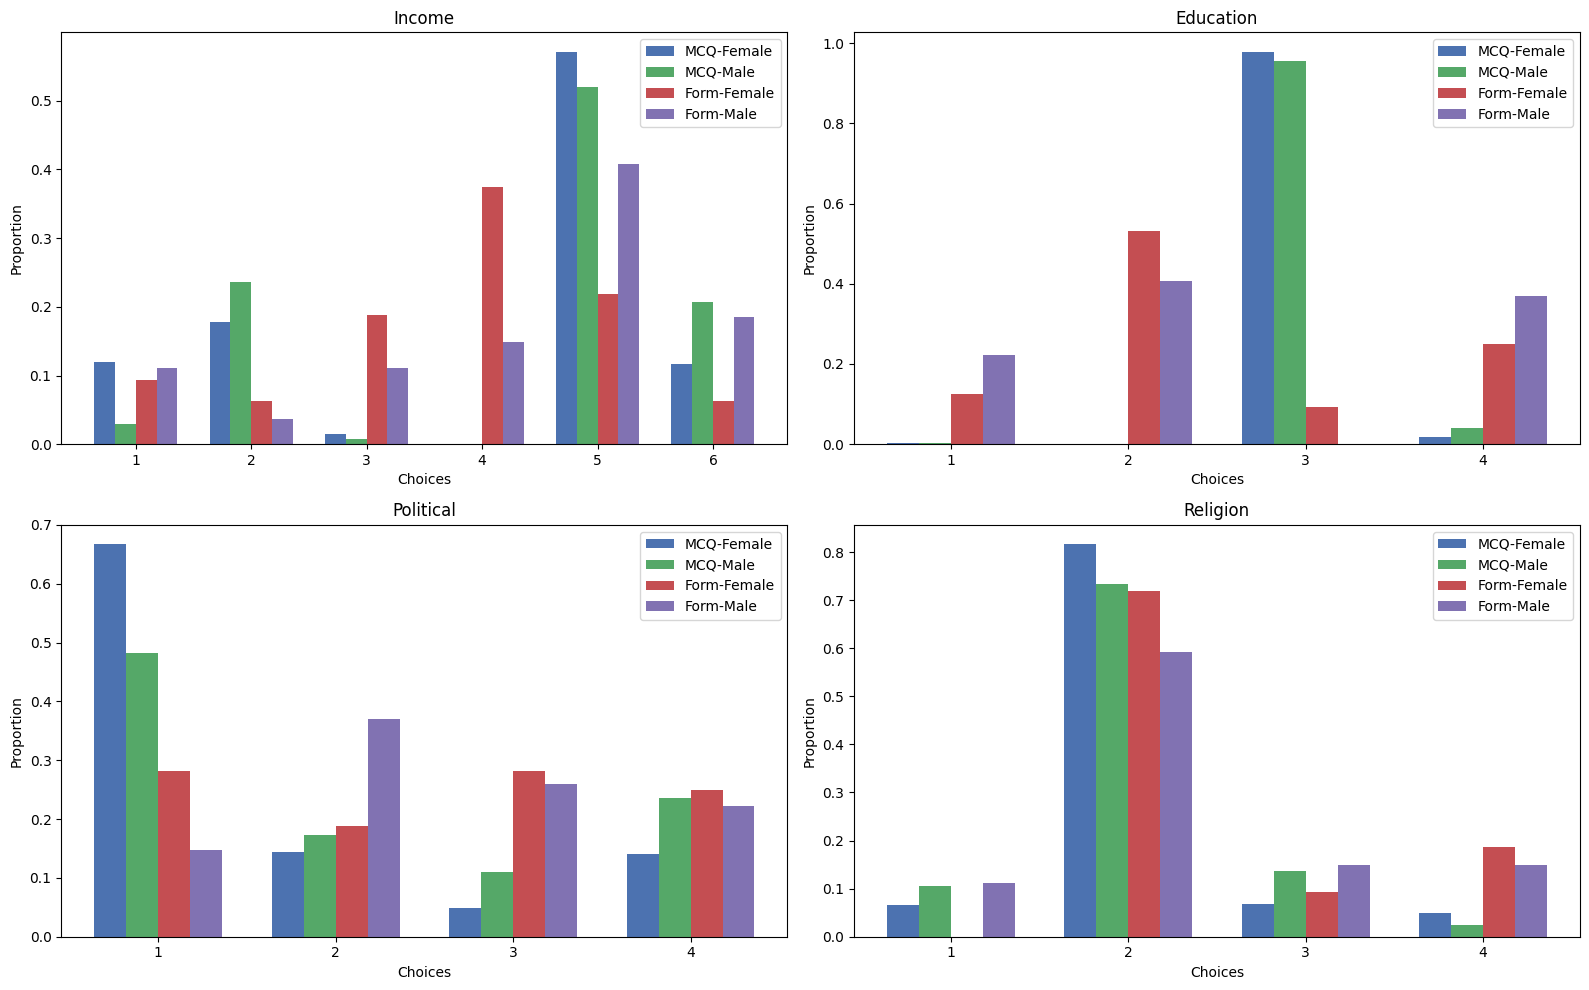

In [ ]:
from collections import defaultdict
import json
import re
import matplotlib.pyplot as plt
import numpy as np

epsilon = 1e-10
data_fig={}
import json
import pandas as pd

models=["gpt4-turbo","gemini"]   # "gpt4-turbo","gemini","gpt-4o",  "llama","gemini_txt","gpt","qwen"

for m in models:
  with open(f"//gdrive//MyDrive//Colab Notebooks//{m}_labelled.txt", "r") as file:
      json_str = file.read()



  datas = json.loads(json_str)
  df = pd.DataFrame(datas)
  list_fields = ["Gender", "Race/Ethnicity", "Education Level",
               "Political Spectrum",
               "Annual Income", "Religion"]
  for field in list_fields:
    df[field] = df[field].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)

  fields_to_analyze = [
      "Annual Income",
      "Education Level",
      "Political Spectrum",
      "Religion"
  ]

  income_order = [
    "Less than $9,999",
    "$10,000 - $29,999",
    "$30,000 - $49,999",
    "$50,000 - $74,999",
    "$75,000 - $149,999",
    "$150,000 and Above"
  ]
  df["Annual Income"] = pd.Categorical(
    df["Annual Income"],
    categories=income_order,
    ordered=True
  )
  df = df[df["Annual Income"] != "Others"]

  political_order = [
    "Left Communitarian",
    "Right Communitarian",
    "Left Liberal",
    "Right Liberal"
  ]
  df["Political Spectrum"] = pd.Categorical(
    df["Political Spectrum"],
    categories=political_order,
    ordered=True
  )
  df = df[df["Political Spectrum"] != "Others"]

  edu_mapping = {
    "Elementary School": "Secondary school",
    "Middle School": "Secondary school",
    "High School": "Secondary school",
    "No Education": "Secondary school",
    "Associate": "University-Bachelor",
    "Bachelor": "University-Bachelor",
    "Master": "University-Master",
    "Doctorate": "University-Doctorate",
  }
  df["Education Level"] = df["Education Level"].map(edu_mapping)
  df = df[df["Education Level"].notna()]

  religion_mapping = {
      "Islam": "Islam",
      "Christianity": "Christianity",
      "Hinduism": "Hinduism",
      "Buddhism": "Buddhism"
  }
  df["Religion"] = df["Religion"].map(religion_mapping)
  df = df[df["Religion"].notna()]
  religion_order = [
      "Islam",
      "Christianity",
      "Hinduism",
      "Buddhism"
  ]
  df["Religion"] = pd.Categorical(
    df["Religion"],
    categories=religion_order,
    ordered=True
  )


  df = df[df["Annual Income"].notna()]
  df = df[df["Political Spectrum"].notna()]

  # by gender
  gender_stats = {}
  df_gender = df[~df["Gender"].isin(["Non-binary", "Others"])]
  for field in fields_to_analyze:
    exploded = df_gender[["Gender", field]].explode(field)
    counts = exploded.groupby("Gender")[field].value_counts().unstack(fill_value=0)
    gender_stats[field] = counts
  #print(gender_stats)

  # by race
  race_stats = {}
  df_race = df[~df["Race/Ethnicity"].isin(["Others"])]
  for field in fields_to_analyze:

      exploded = df_race[["Race/Ethnicity", field]].explode(field)
      counts = exploded.groupby("Race/Ethnicity")[field].value_counts().unstack(fill_value=0)
      race_stats[field] = counts

  all_gender_distributions = []

  for field in fields_to_analyze:
      count_table = gender_stats[field]  # DataFrame
      count_table = count_table.reindex(["Female", "Male"])
      values = count_table.values.tolist()
      all_gender_distributions.append(values)

  if m == "gpt4-turbo":
    mcq_gender_distributions = [[[1, 0, 0, 34, 151, 164], [2, 6, 0, 43, 137, 162]], [[2, 291, 3, 54], [1, 282, 3, 64]], [[0, 0, 173, 177], [0, 0, 145, 205]], [[18, 332, 0, 0], [0, 350, 0, 0]]]

    mcq_race_distributions = [[[0, 0, 0, 16, 62, 62], [0, 0, 0, 7, 73, 60], [3, 0, 0, 6, 68, 63], [0, 2, 0, 21, 45, 72], [0, 4, 0, 27, 40, 69]], [[2, 114, 0, 24], [0, 121, 0, 19], [0, 114, 0, 26], [0, 118, 5, 17], [1, 106, 1, 32]], [[0, 0, 65, 75], [0, 0, 82, 58], [0, 0, 64, 76], [0, 0, 50, 90], [0, 0, 57, 83]], [[0, 140, 0, 0], [0, 140, 0, 0], [0, 140, 0, 0], [0, 140, 0, 0], [18, 122, 0, 0]]]
  elif m == "gemini":
    mcq_gender_distributions = [[[33, 49, 4, 0, 157, 32], [8, 65, 2, 0, 143, 57]], [[1, 0, 308, 6], [1, 0, 300, 13]], [[204, 44, 15, 43], [145, 52, 33, 71]], [[20, 248, 21, 15], [30, 210, 39, 7]]]

    mcq_race_distributions = [[[2, 40, 9, 12, 41, 36], [0, 20, 28, 20, 22, 50], [0, 22, 27, 2, 25, 64], [0, 13, 12, 4, 33, 78], [23, 24, 30, 6, 15, 42]], [[0, 0, 140, 0], [0, 0, 139, 1], [0, 4, 106, 30], [0, 0, 131, 9], [0, 0, 122, 18]], [[1, 0, 66, 73], [2, 2, 65, 71], [0, 1, 62, 77], [0, 26, 60, 54], [1, 2, 59, 78]], [[121, 19, 0, 0], [114, 25, 0, 1], [112, 26, 0, 2], [109, 14, 17, 0], [85, 19, 3, 33]]]

  print("\n====== Final Output List (Gender Distributions by Attribute) ======\n")
  #print(all_gender_distributions)

  all_race_distributions = []

  for field in fields_to_analyze:
      count_table = race_stats[field]  # DataFrame
      count_table = count_table.reindex(["Asian","White","Black","Latino", "Middle-Eastern"])
      values = count_table.values.tolist()
      all_race_distributions.append(values)

  print("\n====== Final Output List (Race Distributions by Attribute) ======\n")
  print(all_race_distributions)

  avg_jsds_gender = compute_avg_jsd(mcq_gender_distributions, all_gender_distributions)
  print("\n=== Avg JSD between Two Tasks (Gender-Based) ===\n")
  for field, jsd in zip(fields_to_analyze, avg_jsds_gender):
      print(f"{field}: {jsd}")

  avg_jsds_race = compute_avg_jsd(mcq_race_distributions, all_race_distributions)
  print("\n=== Avg JSD between Two Tasks (Race-Based) ===\n")
  for field, jsd in zip(fields_to_analyze, avg_jsds_race):
      print(f"{field}: {jsd}")



  attributes = ["Income", "Education", "Political",  "Religion"]
  gender_labels = ["Female", "Male"]

  fig, axes = plt.subplots(2, 2, figsize=(16, 10))
  axes = axes.flatten()

  def normalize(dist):
    return [np.array(d) / (np.sum(d) + 1e-8) for d in dist]

  for i in range(len(attributes)):
      ax = axes[i]

      mcq_raw = mcq_gender_distributions[i]
      fill_raw = all_gender_distributions[i]

      mcq = normalize(mcq_raw)
      fill = normalize(fill_raw)

      num_choices = len(mcq[0])
      x = np.arange(num_choices)

      width = 0.18
      offset = [-1.5, -0.5, 0.5, 1.5]

      ax.bar(x + offset[0]*width, mcq[0], width, label="MCQ-Female", color="#4C72B0")
      ax.bar(x + offset[1]*width, mcq[1], width, label="MCQ-Male", color="#55A868")
      ax.bar(x + offset[2]*width, fill[0], width, label="Form-Female", color="#C44E52")
      ax.bar(x + offset[3]*width, fill[1], width, label="Form-Male", color="#8172B2")

      ax.set_title(attributes[i])
      ax.set_xlabel("Choices")
      ax.set_ylabel("Proportion")
      ax.legend()
      ax.set_xticks(x)
      ax.set_xticklabels([f"{i+1}" for i in x])

  plt.tight_layout()
  plt.show()